# Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib import get_data_path
import plotly.express as px
import json
import seaborn as sns
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibrationDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score,make_scorer,average_precision_score,RocCurveDisplay,PrecisionRecallDisplay, silhouette_score,confusion_matrix,classification_report,precision_recall_curve,precision_score,recall_score,f1_score, adjusted_rand_score)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.svm import SVC
from sklearn.mixture import GaussianMixture

# Data Acquisition and Preprocessing

The CMS Hospital Cost Reports are provided as separate annual CSV files. Below loads each year individually, standardizes column structures across years, adds an explicit "year" variable, and concatenates all years into a single dataframe. 

In [2]:
# #list to store yearly dataframes
# cp_df = []
# #file path for annual cost reports
# cp_files = ["/work/Cost Reports/Hospital_Provider_Cost_Report_2015.csv",
#             "/work/Cost Reports/Hospital_Provider_Cost_Report_2016.csv",
#             "/work/Cost Reports/Hospital_Provider_Cost_Report_2017.csv",
#             "/work/Cost Reports/Hospital_Provider_Cost_Report_2018.csv",
#             "/work/Cost Reports/Hospital_Provider_Cost_Report_2019.csv",
#             "/work/Cost Reports/Hospital_Provider_Cost_Report_2020.csv",
#             "/work/Cost Reports/Hospital_Provider_Cost_Report_2021.csv",
#             "/work/Cost Reports/Hospital_Provider_Cost_Report_2022.csv",
#             "/work/Cost Reports/Hospital_Provider_Cost_Report_2023_updated.csv"]
# #load 2015 first to get column names
# df_2015 = pd.read_csv(cp_files[0])
# df_2015['year'] = 2015
# cp_df.append(df_2015)
# #load remaining years
# for f in cp_files[1:]:
#     #pull the year from the file
#     year = int(re.search(r"(\d{4})", f).group(1))
#     #skip first row (column headers)
#     df = pd.read_csv(f,skiprows=1,header=None)
#     #use 2015 column headers to remain consitent 
#     df.columns = df_2015.columns.drop('year',errors='ignore')
#     #add the year column
#     df['year'] = year
#     cp_df.append(df)
# #combine all years into one dataframe
# cp_df = pd.concat(cp_df, ignore_index=True)

Some hospitals submit more than one cost report for the same year,to handle this we kept the latest version date, summed values for key financial fields, and merged everything back together.

In [3]:
# #convert FY end date to datetime
# cp_df['Fiscal Year End Date'] = pd.to_datetime(cp_df['Fiscal Year End Date'], errors='coerce')
# #key financial fields that need to be summed for multiple filings
# sum_columns = ["Total Discharges (V + XVIII + XIX + Unknown)",
#                 "Total Days (V + XVIII + XIX + Unknown)",
#                 "Inpatient Revenue",
#                 "Outpatient Revenue",
#                 "Total Patient Revenue",
#                 "Net Patient Revenue",
#                 "Less Total Operating Expense",
#                 "Total Costs",
#                 "Net Income",
#                 "Cost of Charity Care",
#                 "Total Bad Debt Expense",
#                 "Cost of Uncompensated Care",
#                 "Total Unreimbursed and Uncompensated Care"]
# #sort by FY end date in order to keep latest record
# cp_latest = (cp_df.sort_values("Fiscal Year End Date")
#                 .groupby(["Provider CCN","year"], as_index=False)
#                 .tail(1)
#                 .copy())
# #sum key financial fields across duplicate filings
# cp_sum = (cp_df.groupby(["Provider CCN","year"], as_index=False)[sum_columns]
#                 .sum())
# #merge summed records back into the latest record
# cp_clean = cp_latest.merge(cp_sum, 
#                             on=["Provider CCN","year"],
#                             how="left",
#                             suffixes=("","_sum"))
# #replace the original financials with the summed values
# for col in sum_columns:
#     cp_clean[col] = cp_clean[f"{col}_sum"]
#     cp_clean.drop(columns=[f"{col}_sum"], inplace=True)

In [4]:
# #creating a list of unique CCN for each year to assist in extracting applicable data in the POS files
# #make sure Provider CCN is treated as a string
# cp_df["Provider CCN"]=cp_df["Provider CCN"].astype(str)
# #dictionary to store CCNs for each year
# cp_ccn = {}
# #loop through each year
# for year, group in cp_df.groupby("year"):
#     #get unique hospital ID's
#     ccn = set(group["Provider CCN"].unique())
#     #store in dictionary
#     cp_ccn[year]=ccn

The Provider of Services files are large so we chose only to load applicable columns, filter hospitals that show up in cp_ccn dictionary created above, adds an explicit "year" variable, and concatenates all years into a single dataframe.

In [5]:
# #list to store yearly dataframes
# pos_keep = []
# #only keep the POS columns that are needed
# columns = ["PRVDR_CTGRY_SBTYP_CD", #hostpital subtype
#             "PRVDR_CTGRY_CD", #hospital type
#             "CHOW_CNT", #number of ownership changes
#             "CHOW_DT", #date of most recent ownership
#             "PRVDR_NUM", #Hospital CCN Number (join key)
#             "FIPS_STATE_CD",
#             "FIPS_CNTY_CD",
#             "CBSA_URBN_RRL_IND", #urban/rural indicicator
#             "CBSA_CD", #metropolitan area code
#             "OVRRD_BED_CNT_SW",#bed count override indicator
#             "CRTFD_BED_CNT", #certified bed count
#             "MLT_OWND_FAC_ORG_SW", #multi-facility system indicator
#             "PGM_PRTCPTN_CD", #Medicare/Medicaid participation
#             ]
# #file paths for yearly POS datasets
# pos_files = ["/work/Provider of Service/POS_File_Hospital_Non_Hospital_Facilities_Q4_2015.csv",
#             "/work/Provider of Service/POS_File_Hospital_Non_Hospital_Facilities_Q4_2016.csv",
#             "/work/Provider of Service/POS_File_Hospital_Non_Hospital_Facilities_Q4_2017.csv",
#             "/work/Provider of Service/POS_File_Hospital_Non_Hospital_Facilities_Q4_2018.csv",
#             "/work/Provider of Service/POS_File_Hospital_Non_Hospital_Facilities_Q4_2019.csv",
#             "/work/Provider of Service/POS_File_Hospital_Non_Hospital_Facilities_Q4_2020.csv",
#             "/work/Provider of Service/POS_File_Hospital_Non_Hospital_Facilities_Q4_2021.csv",
#             "/work/Provider of Service/POS_File_Hospital_Non_Hospital_Facilities_Q4_2022.csv",
#             "/work/Provider of Service/POS_File_Hospital_Non_Hospital_Facilities_Q4_2023.csv"]
# #loop through each POS file
# for f in pos_files:
#     #pull the year from the filename
#     year = int(re.search(r"(\d{4})", f).group(1))
#     #get the list of CCNs we want to keep
#     keep_ccn = cp_ccn.get(year,set())
#     #read the POS file in chunks so we don't use a lot of memory
#     for item in pd.read_csv(f,encoding="latin-1", chunksize=200_000, low_memory=False, usecols=columns):
#         #make sure PRVDR NUM is a string
#         item["PRVDR_NUM"] = item["PRVDR_NUM"].astype(str)
#         #keep only rows where the CCN is in the cost report list
#         filters = item[item["PRVDR_NUM"].isin(keep_ccn)].copy()
#         #if there are matches in the chunk, tag the year and store it
#         if not filters.empty:
#             filters["year"]=year
#             pos_keep.append(filters)
# #combine all filtered chunks into one dataframe
# if len(pos_keep) > 0:
#     pos_df = pd.concat(pos_keep, ignore_index=True)
# else:
#     pos_df=pd.DataFrame(columns=columns+["year"])

Combined the cleaned cost report data with the POS data.

In [6]:
# #verify CCNs are stings and remove any extra spaces
# cp_clean["Provider CCN"]=cp_clean["Provider CCN"].astype(str).str.strip()
# pos_df["PRVDR_NUM"]=pos_df["PRVDR_NUM"].astype(str).str.strip()
# #inner join the data where CCN is in both cp and pos
# merged_df = cp_clean.merge(pos_df, left_on=["Provider CCN","year"], right_on=["PRVDR_NUM","year"], how="inner")
# #drop dublicate join column
# merged_df = merged_df.drop(columns=["PRVDR_NUM"])

In [7]:
# #create merged_df csv
# output_path = "/work/merged_data.csv"
# merged_df.to_csv(output_path, index=False)

# Supervised Learning

In [8]:
#load merged dataset
merged_df = pd.read_csv("merged_data.csv")

# merged_df.head(5)

Created key financial and operational ratios that may signal distress. 

In [9]:
#operating margin
merged_df["operating_margin"] = (merged_df["Net Income from Service to Patients"]/merged_df["Net Patient Revenue"])

#net margin
merged_df["net_margin"] = (merged_df["Net Income"]/merged_df["Net Patient Revenue"])

#liquidity 
merged_df["liquidity"] = (merged_df["Total Current Assets"]/merged_df["Total Current Liabilities"])

#leverage
merged_df["leverage"] = (merged_df["Total Liabilities"]/merged_df["Total Assets"])

#average length of stay
merged_df["avg_los"] = (merged_df["Total Days (V + XVIII + XIX + Unknown)"]/merged_df["Total Discharges (V + XVIII + XIX + Unknown)"])

#occupancy rate
merged_df["occupancy_rate"] = (merged_df["Total Days (V + XVIII + XIX + Unknown)"]/(merged_df["CRTFD_BED_CNT"]*365))

#financial features
fin_features = ["avg_los",
                "occupancy_rate",
                "operating_margin",
                "net_margin",
                "liquidity",
                "leverage"]

#payor mix
merged_df["payor mix"] = (merged_df["Net Revenue from Medicaid"] /merged_df["Net Patient Revenue"])

#care burden
merged_df["uncomp_care_ratio"] = (merged_df["Cost of Uncompensated Care"] /merged_df["Total Costs"])

#resident ratio
merged_df["resident_bed_ratio"] = (merged_df["Number of Interns and Residents (FTE)"] /merged_df["CRTFD_BED_CNT"])

#utilization features
util_features = ["Total Discharges (V + XVIII + XIX + Unknown)",
                "Total Days (V + XVIII + XIX + Unknown)",
                "CRTFD_BED_CNT"]

#structural features
struc_features = ["PRVDR_CTGRY_SBTYP_CD",
                 "PRVDR_CTGRY_CD",
                 "FIPS_STATE_CD",
                 "CBSA_URBN_RRL_IND",
                 "PGM_PRTCPTN_CD"]

feature_cols = util_features + struc_features + fin_features

Before we began modeling we wanted to verify that the impact of dropping hospitals with missing financials had on the distress label. Merging the Cost Report and Provider of Services datasets did no materially alter the financial distress, 4.6% before merge vs 4.55% after merge, indicating that dataset alignment did not introduce meaningful class imbalance bias.

In [10]:
# #calculate financial ratios
# cp_clean["operating_margin"] = (cp_clean["Net Income from Service to Patients"]/cp_clean["Net Patient Revenue"])
# cp_clean["liquidity"] = (cp_clean["Total Current Assets"]/cp_clean["Total Current Liabilities"])
# #remove hospital where ratios are not calculated
# cp_clean = cp_clean.dropna(subset=["operating_margin","liquidity"])
# #set low liquidity to bottom 10%
# liquidity_cutoff = (cp_clean.loc[cp_clean["year"].between(2017,2019),"liquidity"].quantile(0.10))
# #negative operating margin and low liquidity signal distress label
# cp_clean["distress_B"]=((cp_clean["operating_margin"]<0)&(cp_clean["liquidity"] <= liquidity_cutoff)).astype(int)

# print("Distress rate BEFORE merge")
# print(cp_clean["distress_B"].mean())

# print("Distress rate by year BEFORE merge")
# print(cp_clean.groupby("year")["distress_B"].mean())

# print("Distress rate AFTER merge")
# print(merged_df["distress_B"].mean())

# print("Distress rate by year AFTER merge")
# print(merged_df.groupby("year")["distress_A"].mean())

Before modeling we wanted to explore financial distress and the parameters we wanted to set. <br> Distress A: hospital has negative operating margin and is in the bottom 10% of liquidity <br> Distress B: hospital has negative operating margin for 2 consecutive years and is in the bottom 10% of liquidity

In [11]:
#replace infinite values created by ratios calculations with Nan
merged_df[feature_cols] = merged_df[feature_cols].replace([np.inf,-np.inf],np.nan)
#remove hospital with incomplete financials
merged_df = merged_df.dropna(subset=["operating_margin","liquidity"])
#use 2017-2019 to set the liquidity cutoff of bottom 10%
liquidity_cutoff = (merged_df.loc[merged_df["year"].between(2017,2019),"liquidity"].quantile(0.10))
#negative operating margin and low liquidity signal distress label
merged_df["distress_A"]=((merged_df["operating_margin"]<0)&(merged_df["liquidity"] <= liquidity_cutoff)).astype(int)
#flag each hospital where operting margin is negative
merged_df["neg_margin"] = (merged_df["operating_margin"]<0).astype(int)
#rolling 2 year sum of negative margin flags
merged_df["neg_margin_roll"]=(merged_df.groupby("Provider CCN")["neg_margin"]
                                .rolling(window=2)
                                .sum()
                                .reset_index(level=0, drop=True))
#True if hospital has two consecutive years as negative margin
merged_df["neg_margin_yrs"] = (merged_df["neg_margin_roll"] == 2)
#2 years of negative operating margin and low liquidity signal distress label
merged_df["distress_B"] = (merged_df["neg_margin_yrs"] & (merged_df["liquidity"] <= liquidity_cutoff)).astype(int)
#keep on 2017 and onward for modeling
merged_df = merged_df[merged_df["year"] >= 2017]

Before modeling we wanted to determine the appropriate distress label; we chose distress_B as our final label becasue it reflects a more persistent financial problem rather than a single bad year. 

In [12]:
print("ORIGINAL Distress rate")
print(merged_df["distress_A"].mean())

print("ORIGINAL Distress rate by year")
print(merged_df.groupby("year")["distress_A"].mean())

print("Distress_B rate")
print(merged_df["distress_B"].mean())

print("Distress_B rate by year")
print(merged_df.groupby("year")["distress_B"].mean())

ORIGINAL Distress rate
0.05693120443880412
ORIGINAL Distress rate by year
year
2017    0.045975
2018    0.051198
2019    0.053837
2020    0.056953
2021    0.052664
2022    0.069052
2023    0.069080
Name: distress_A, dtype: float64
Distress_B rate
0.04663105392084526
Distress_B rate by year
year
2017    0.038414
2018    0.043006
2019    0.045586
2020    0.044689
2021    0.043297
2022    0.052829
2023    0.058738
Name: distress_B, dtype: float64


The below chart was used to visually compare distress A and B; with both distress rates begin increasing in 2022.

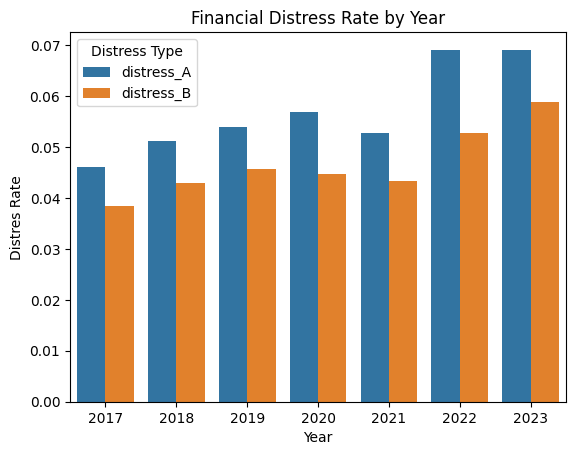

In [13]:
#groubpy distress rates by year
distress_rates = (merged_df.groupby("year")[["distress_A","distress_B"]].mean().reset_index())
#convert to long format for easier plotting
distress_long = distress_rates.melt(id_vars="year",
                                    value_vars = ["distress_A","distress_B"],
                                    var_name = "Distress Type",
                                    value_name = "Rate")
#plot comparison
sns.barplot(data=distress_long,
            x="year",
            y="Rate",
            hue = "Distress Type")
plt.title("Financial Distress Rate by Year")
plt.ylabel("Distres Rate")
plt.xlabel("Year")
plt.show()

Initial modeling showed unrealistically strong performance. After reviewing the feature set, we found variables that were directly used to construct the distress label. To avoid data leakage, we removed these variables so the model had to learn the predictive patterns instead of cheating. 

In [14]:
#vairables identified as apart of the distress definition
leakage_cols = ["Net Income",
                # "Total Patient Revenue",
                # "Total Income",
                "Total Current Assets",
                "Total Current Liabilities",
                "operating_margin",
                "Net Income from Service to Patients",
                "Net Patient Revenue",
                "liquidity"]
#remove leakage columns from utilization features
clean_util = []
for col in util_features:
    if col not in leakage_cols:
        clean_util.append(col)

util_features = clean_util
#remove leakage columns from structural features
clean_struc = []
for col in struc_features:
    if col not in leakage_cols:
        clean_struc.append(col)

struc_features = clean_struc
#remove leakage columns from financial features
clean_fin = []
for col in fin_features:
    if col not in leakage_cols:
        clean_fin.append(col)
#final clean features
fin_features = clean_fin

Train/Test Split and Feature Preprocessing

In [15]:
#define features and target label
X = merged_df[feature_cols]
y = merged_df["distress_B"]
#train on earlier years
X_train = X[merged_df["year"].between(2017,2019)]
y_train = y[merged_df["year"].between(2017,2019)]
#test on later years
X_test = X[merged_df["year"].between(2022,2023)]
y_test = y[merged_df["year"].between(2022,2023)]
#numeric - fill missing values with median, then scale
numeric_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                                ("scale", StandardScaler())])
#categorical - fill missing values with most common catefore, then one-hot encode
cat_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown ="ignore"))])
#apply the right preprocessing to each feature group
preprocessor = ColumnTransformer(transformers=[
                                ("num", numeric_pipe, fin_features + util_features),
                                ("cat", cat_pipe, struc_features)])

## Logistic Regression

Start modeling with a simple baseline model. 

In [16]:
#logistic regression
log_reg = Pipeline(steps=[("preprocess",preprocessor),
                            ("clf", LogisticRegression(max_iter=2000,
                            class_weight="balanced",
                            solver="lbfgs"))])

log_reg.fit(X_train,y_train)

log_proba_test = log_reg.predict_proba(X_test)[:,1]

log_roc = roc_auc_score(y_test,log_proba_test)
log_pr = average_precision_score(y_test,log_proba_test)

print(f"ROC-AUC: {log_roc:.4f}")
print(f"PR-AUC: {log_pr:.4f}")

ROC-AUC: 0.7374
PR-AUC: 0.1638


## Gradient Boosting

Next, train a GB model to capute non-linear relationships. 

In [17]:
#Gradient Boosting model
gboost_model = Pipeline(steps=[("preprocess",preprocessor),
                                ("clf", GradientBoostingClassifier(random_state=42))])

gboost_model.fit(X_train, y_train)
gboost_proba_test = gboost_model.predict_proba(X_test)[:,1]

gboost_roc = roc_auc_score(y_test, gboost_proba_test)
gboost_pr = average_precision_score(y_test, gboost_proba_test)

print(f"ROC-AUC: {gboost_roc:.4f}")
print(f"PR-AUC: {gboost_pr:.4f}")

ROC-AUC: 0.8932
PR-AUC: 0.3989


## Support Vector Machine

Lastly, train a SVC for a different modeling approach.

In [18]:
#Support Vector Calssifier
svc_base = Pipeline([("preprocess",preprocessor),
                        ("clf", SVC(kernel = "rbf",
                                    class_weight = "balanced",
                                    probability = True,
                                    random_state = 42))])

svc_base.fit(X_train,y_train)

svc_proba_test = svc_base.predict_proba(X_test)[:,1]

svc_roc = roc_auc_score(y_test, svc_proba_test)
svc_pr = average_precision_score(y_test, svc_proba_test)

print(f"ROC-AUC: {svc_roc:.4f}")
print(f"PR-AUC: {svc_pr:.4f}")

ROC-AUC: 0.7744
PR-AUC: 0.1763


### Summary

The below graphs outline that Gradient Boosting outperforms Logistic Regression and SVC with the highest ROC-AUC and PR-AUC. While all models show reasonable discrimination the Precision Recall curve shows that GB handles class imbalance much better. This suggests that non linear tree based methods capture distress patterns more effectively than linear or magin based models for this dataset.

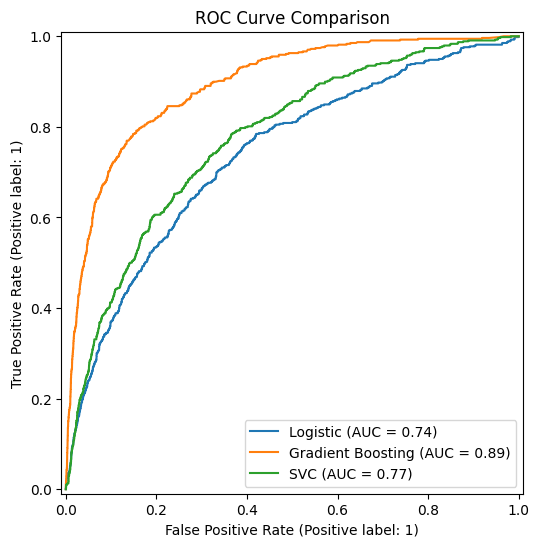

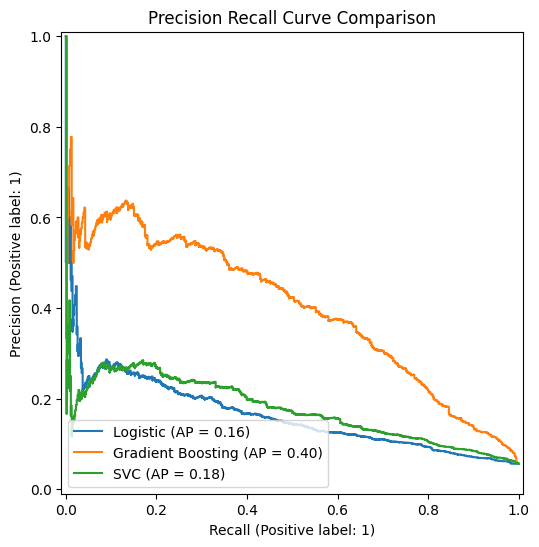

In [19]:
#ROC curve
fig, ax = plt.subplots(figsize=(7,6))
RocCurveDisplay.from_predictions(y_test,log_proba_test, name = "Logistic", ax=ax)
RocCurveDisplay.from_predictions(y_test,gboost_proba_test, name = "Gradient Boosting",ax=ax)
RocCurveDisplay.from_predictions(y_test,svc_proba_test, name = "SVC",ax=ax)
ax.set_title("ROC Curve Comparison")
plt.show()

#Precision Recall curve
fig, ax = plt.subplots(figsize=(7,6))
PrecisionRecallDisplay.from_predictions(y_test,log_proba_test, name = "Logistic",ax=ax)
PrecisionRecallDisplay.from_predictions(y_test,gboost_proba_test, name = "Gradient Boosting",ax=ax)
PrecisionRecallDisplay.from_predictions(y_test,svc_proba_test, name = "SVC",ax=ax)
ax.set_title("Precision Recall Curve Comparison")
plt.show()

## Tuning

In [20]:
#for all models we utilize average precision for scoring
ap_scorer = make_scorer(average_precision_score, response_method = "predict_proba")
#base model pipeline
gb = Pipeline(steps=[("preprocess",preprocessor),
                                ("clf", GradientBoostingClassifier(random_state=42))])
#hyperparameter grid search
gb_grid = {"clf__n_estimators": [200,500],
            "clf__learning_rate": [0.01,0.05,0.1],
            "clf__max_depth": [2,3],
            "clf__min_samples_leaf": [1,10,30]}
#grid search with cross validation on training set
gb_search = GridSearchCV(gb,
                            param_grid = gb_grid,
                            scoring = ap_scorer,
                            cv = 3,
                            n_jobs = -1,
                            verbose = 1)
#fit grid search
gb_search.fit(X_train,y_train)

print("Best Params", gb_search.best_params_)
print("Best CV PR AUC", gb_search.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Params {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__min_samples_leaf': 30, 'clf__n_estimators': 500}
Best CV PR AUC 0.48689065219598016


In [21]:
#base model pipeline
log = Pipeline(steps=[("preprocess",preprocessor),
                            ("clf", LogisticRegression(max_iter=2000,
                            class_weight="balanced",
                            solver="lbfgs"))])
#hyperparameter grid search
log_grid = {"clf__C": [0.01,0.1,1,10,100]}
#grid search with cross validation on training set
log_search = GridSearchCV(log,
                            param_grid = log_grid,
                            scoring = ap_scorer,
                            cv = 3,
                            n_jobs = -1,
                            verbose = 1)
#fit grid search
log_search.fit(X_train,y_train)

print("Best Params", log_search.best_params_)
print("Best CV PR AUC", log_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Params {'clf__C': 1}
Best CV PR AUC 0.17978760616214481


In [22]:
#base model pipeline
svc = Pipeline(steps = [("preprocess",preprocessor),
                        ("clf", SVC(kernel = "rbf",
                                    class_weight = "balanced",
                                    probability = True,
                                    random_state = 42))])
#hyperparameter grid search
svc_grid = {"clf__C": [0.1,1,10],
            "clf__gamma": ["scale",0.1,0.01]}
#grid search with cross validation on training set
svc_search = GridSearchCV(svc,
                            param_grid = svc_grid,
                            scoring = ap_scorer,
                            cv = 3,
                            n_jobs = -1,
                            verbose = 1)
#fit grid search
svc_search.fit(X_train,y_train)

print("Best Params", svc_search.best_params_)
print("Best CV PR AUC", svc_search.best_score_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Params {'clf__C': 10, 'clf__gamma': 0.1}
Best CV PR AUC 0.29686996813402905


Evaluated the tuned models using 5 fold cross validation on the training set. Once again the summary table outline that GB outperforms the other models across both cross validation and test performance. Most importantly it maintains strong performance on the test set, 2022-2023, showing good generalization rather than overfitting. 

In [23]:
#cross validation evaluation 5-fold
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#evaluate both ROC-AUC and PR-AUC
scoring = {"roc_auc": "roc_auc",
            "pr_auc": "average_precision"}
#best tuned models
best_gb = gb_search.best_estimator_
best_log = log_search.best_estimator_
best_svc = svc_search.best_estimator_
#cross validated results on training data
gb_cv = cross_validate(best_gb, X_train, y_train, cv=cv5, scoring = scoring, n_jobs=-1)
log_cv = cross_validate(best_log, X_train, y_train, cv=cv5, scoring = scoring, n_jobs=-1)
svc_cv = cross_validate(best_svc, X_train, y_train, cv=cv5, scoring = scoring, n_jobs=-1)
#create a summary table
summary = pd.DataFrame({"Model": ["Logistic (tuned)", "Gradient Boosting (tuned)", "SVC (tuned)"],
                        "CV ROC-AUC (mean)": [log_cv["test_roc_auc"].mean(), gb_cv["test_roc_auc"].mean(), svc_cv["test_roc_auc"].mean()],
                        "CV ROC-AUC (std)": [log_cv["test_roc_auc"].std(), gb_cv["test_roc_auc"].std(), svc_cv["test_roc_auc"].std()],
                        "CV PR-AUC (mean)": [log_cv["test_pr_auc"].mean(), gb_cv["test_pr_auc"].mean(), svc_cv["test_pr_auc"].mean()],
                        "CV PR-AUC (std)": [log_cv["test_pr_auc"].std(), gb_cv["test_pr_auc"].std(), svc_cv["test_pr_auc"].std()]})

#test set evaluation
gb_test_proba = best_gb.predict_proba(X_test)[:,1]
log_test_proba = best_log.predict_proba(X_test)[:,1]
svc_test_proba = best_svc.predict_proba(X_test)[:,1]

summary["Test ROC-AUC"] = [roc_auc_score(y_test,log_test_proba),
                            roc_auc_score(y_test,gb_test_proba),
                            roc_auc_score(y_test,svc_test_proba)]

summary["Test PR-AUC"] = [average_precision_score(y_test,log_test_proba),
                            average_precision_score(y_test,gb_test_proba),
                            average_precision_score(y_test,svc_test_proba)]

summary

,Model,CV ROC-AUC (mean),CV ROC-AUC (std),CV PR-AUC (mean),CV PR-AUC (std),Test ROC-AUC,Test PR-AUC
0,Logistic (tuned),0.779730,0.014344,0.191561,0.033861,0.737389,0.163762
1,Gradient Boosting (tuned),0.916881,0.007428,0.508627,0.033486,0.886098,0.395271
2,SVC (tuned),0.833921,0.008859,0.245250,0.040401,0.750646,0.175106


## In Depth Evaluation

Now that we have settled on Gradient Boosting as the best performing model, below is a deep evaluation.

### Abalation

In [24]:
#set up cross-validation
cv5= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#evaluate using ROC-AUC and PR-AUC
scoring = {"roc_auc":"roc_auc",
            "pr_auc": "average_precision"}
#best hyperparameters from grid search
params = gb_search.best_params_
#numeric and categorical features
fin_feats = util_features + fin_features
cat_feats = struc_features
#build preprocessing pipeline
numeric_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                                ("scale", StandardScaler())])

cat_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown ="ignore"))])

preprocessor_full = ColumnTransformer([("num", numeric_pipe, fin_feats),
                                        ("cat", cat_pipe, cat_feats)])
#final GB model using tuned paramaters
gb_full = Pipeline([("preprocess", preprocessor_full),
                        ("clf", GradientBoostingClassifier(random_state=42,
                                                            n_estimators=params["clf__n_estimators"],
                                                            learning_rate=params["clf__learning_rate"],
                                                            max_depth=params["clf__max_depth"],
                                                            min_samples_leaf=params["clf__min_samples_leaf"]))])
#cross validated perfromance on training period
res_full = cross_validate(gb_full, X_train, y_train, cv=cv5, scoring=scoring, n_jobs=-1)

In [25]:
#features less financial
num_no_fin = util_features
cat_feats = struc_features
#build preprocessing pipeline
numeric_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                                ("scale", StandardScaler())])

cat_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown ="ignore"))])

preprocessor_no_fin = ColumnTransformer([("num", numeric_pipe, num_no_fin),
                                        ("cat", cat_pipe, cat_feats)])
#final GB model using tuned paramaters
gb_no_fin = Pipeline([("preprocess", preprocessor_no_fin),
                        ("clf", GradientBoostingClassifier(random_state=42,
                                                            n_estimators=params["clf__n_estimators"],
                                                            learning_rate=params["clf__learning_rate"],
                                                            max_depth=params["clf__max_depth"],
                                                            min_samples_leaf=params["clf__min_samples_leaf"]))])
#cross validated perfromance on training period
res_no_fin = cross_validate(gb_no_fin, X_train, y_train, cv=cv5, scoring=scoring, n_jobs=-1)

In [26]:
#features less utilization
num_no_util = fin_features
cat_feats = struc_features
#build preprocessing pipeline
numeric_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                                ("scale", StandardScaler())])

cat_pipe = Pipeline(steps=[("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown ="ignore"))])

preprocessor_no_util = ColumnTransformer([("num", numeric_pipe, num_no_util),
                                        ("cat", cat_pipe, cat_feats)])
#final GB model using tuned paramaters
gb_no_util = Pipeline([("preprocess", preprocessor_no_util),
                        ("clf", GradientBoostingClassifier(random_state=42,
                                                            n_estimators=params["clf__n_estimators"],
                                                            learning_rate=params["clf__learning_rate"],
                                                            max_depth=params["clf__max_depth"],
                                                            min_samples_leaf=params["clf__min_samples_leaf"]))])
#cross validated perfromance on training period
res_no_util = cross_validate(gb_no_util, X_train, y_train, cv=cv5, scoring=scoring, n_jobs=-1)

Abalation Summary - The below outlines that removing financial features casues a large drop in perfromance, especially in PR-AUC,indicating that fianncail raios are the strongest predictors of distress. On the other hand, removing utilization features resuls in only a modest decline in performance suggesting the features add incremental but smaller predictive value. The low Std across folds indicate stable model performance

In [27]:
#calculate mean and std for ROC-AUC and PR-AUC across the 3 scenarios
abalation_summary = pd.DataFrame({"Model": ["GB All Features (tuned)",
                                            "GB No Financial (tuned)",
                                            "GB No Utilization (tuned)"],
                                            "CV ROC-AUC Mean":[
                                            res_full["test_roc_auc"].mean(),
                                            res_no_fin["test_roc_auc"].mean(),
                                            res_no_util["test_roc_auc"].mean()],
                                            "CV ROC-AUC STD":[
                                            res_full["test_roc_auc"].std(),
                                            res_no_fin["test_roc_auc"].std(),
                                            res_no_util["test_roc_auc"].std()],
                                            "CV PR-AUC Mean":[
                                            res_full["test_pr_auc"].mean(),
                                            res_no_fin["test_pr_auc"].mean(),
                                            res_no_util["test_pr_auc"].mean()],
                                            "CV PR-AUC STD":[
                                            res_full["test_pr_auc"].std(),
                                            res_no_fin["test_pr_auc"].std(),
                                            res_no_util["test_pr_auc"].std()]})

abalation_summary

,Model,CV ROC-AUC Mean,CV ROC-AUC STD,CV PR-AUC Mean,CV PR-AUC STD
0,GB All Features (tuned),0.916881,0.007428,0.508627,0.033486
1,GB No Financial (tuned),0.769923,0.010338,0.195570,0.030716
2,GB No Utilization (tuned),0.910765,0.010005,0.478643,0.041206


### Hyperparameter Sensitivity Analysis

PR-AUC improves as the learning rate increases from 0.01 to 0.1 suggesting slightly more aggressive boosting improves performance. Increasing the number of estimators from 200-500 provides small gains, but the improvement is smaller than the effect of learning rates. Overall performance appears relatively stable across prameter combinations suggesting that model is not overly sensitive. 

param_clf__n_estimators        200       500
param_clf__learning_rate                    
0.01                      0.424358  0.444491
0.05                      0.459047  0.471330
0.10                      0.466756  0.468360


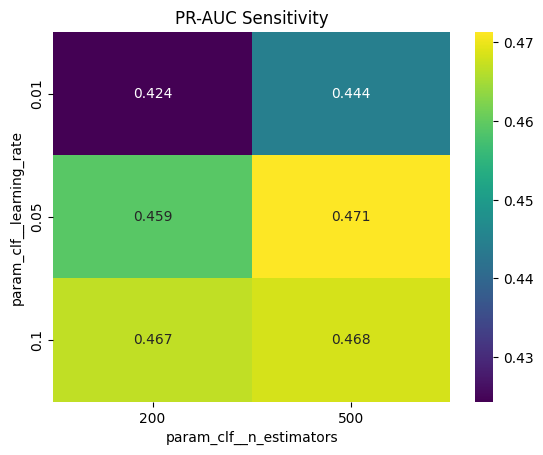

In [29]:
gb_res = pd.DataFrame(gb_search.cv_results_)
#pivot learning rate vs n_estimators
sensitivity = gb_res.pivot_table(index = "param_clf__learning_rate",
                            columns = "param_clf__n_estimators",
                            values = "mean_test_score")
print(sensitivity)
#heatmap visualization
sns.heatmap(sensitivity, annot=True, fmt=".3f", cmap = "viridis")
plt.title("PR-AUC Sensitivity")
plt.show()

### Threshold Tradeoffs

The model acheives strong discrimination however operational performance depends on threshold selection. A 0.20 threshold maximizes F1 score and aligns predicted flag rates with observed distress prevelance, providng a blanced screening policy. 

In [31]:
#set thresholds
thresholds = [0.05,0.1,0.2,0.5]
#empty list to add metrics
results = []
#evaluate metrics across thesholds
best_gb = gb_search.best_estimator_
proba_tune= best_gb.predict_proba(X_test)[:,1]
for t in thresholds:
    preds = (proba_tune >= t).astype(int)
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test,preds)
    f1 = f1_score(y_test, preds)
    flagged_rate = preds.mean()
    results.append([t,precision,recall,f1,flagged_rate])
#build tradeoff summary table
tradeoff_df = pd.DataFrame(results, columns=["Threshold",
                                            "Precision",
                                            "Recall",
                                            "F1 Score",
                                            "Proportion Flagged"])
tradeoff_df

,Threshold,Precision,Recall,F1 Score,Proportion Flagged
0,0.05,0.270787,0.684015,0.387981,0.140931
1,0.10,0.349057,0.550186,0.427128,0.087939
2,0.20,0.444238,0.444238,0.444238,0.055792
3,0.50,0.565421,0.224907,0.321809,0.022192


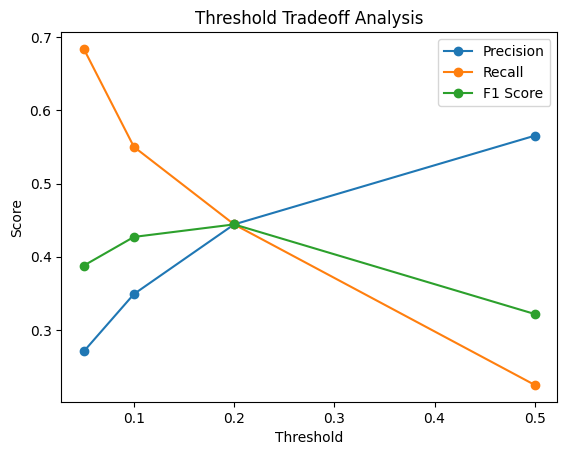

In [32]:
plt.plot(tradeoff_df["Threshold"], tradeoff_df["Precision"], marker="o", label = "Precision")
plt.plot(tradeoff_df["Threshold"], tradeoff_df["Recall"], marker="o", label = "Recall")
plt.plot(tradeoff_df["Threshold"], tradeoff_df["F1 Score"], marker="o", label = "F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tradeoff Analysis")
plt.legend()
plt.show()

## Failure Analysis

We analyzed where the model made mistakes and grouped the errors into clear categories. Most errors were borderline cases, which shows the model performs well on clear signlas but has difficulty when the data is ambiguous. 

In [33]:
#create a copy of the test features
eval_df = X_test.copy()
#add true outcomes
eval_df["true_label"] = y_test.values
#add predicted probabilities
eval_df["pred_proba"] = proba_tune
#add predicted class using 0.5 threshold
eval_df["pred_label"] = (proba_tune >= 0.5).astype(int)

In [34]:
print("Confusion Matrix",confusion_matrix(y_test,eval_df["pred_label"]))

print("Classification Report", classification_report(y_test,eval_df["pred_label"]))

Confusion Matrix [[9012   93]
 [ 417  121]]
Classification Report               precision    recall  f1-score   support

           0       0.96      0.99      0.97      9105
           1       0.57      0.22      0.32       538

    accuracy                           0.95      9643
   macro avg       0.76      0.61      0.65      9643
weighted avg       0.93      0.95      0.94      9643



In [35]:
#false negatives of tuly distress hospitals that was not flagged by the model
false_negatives = eval_df[(eval_df["true_label"] == 1) & (eval_df["pred_label"] == 0)]
#summary stats of missed distress hospitals
false_negatives.describe()
#true positivies of distressed hospitals correctly flagged by the model
tp = eval_df[(eval_df["true_label"] == 1) & (eval_df["pred_label"] == 1)]
#compare average feature values for false negative and true positive
comparison = pd.DataFrame({"FN_mean": false_negatives[fin_features+util_features].mean(),
                            "TP_mean": tp[fin_features+util_features].mean()})
comparison.head()

,FN_mean,TP_mean
avg_los,36.654907,16.487300
occupancy_rate,0.501376,0.317375
net_margin,-0.283476,-0.534956
leverage,0.373299,3.885545
Total Discharges (V + XVIII + XIX + Unknown),4877.654676,3224.578512


In [37]:
#get tuned model predications on the test years
best_gb = gb_search.best_estimator_
proba_tune = best_gb.predict_proba(X_test)[:,1]
pred_test = (proba_tune >= 0.5).astype(int)
#start a failure analysis table with hospital ID + year for the test period
test = merged_df["year"].between(2022,2023)
fail_df = merged_df.loc[test,["Provider CCN","year"]].copy()
#add true labels and model outputs
fail_df["true"] = y_test.values
fail_df["proba"] = proba_tune
fail_df["pred"] = pred_test
#label each row as coorect/false neg/false pos
fail_df["error_type"] = "correct"
fail_df.loc[(fail_df["true"]==1) & (fail_df["pred"]==0), "error_type"] = "false_negative"
fail_df.loc[(fail_df["true"]==0) & (fail_df["pred"]==1), "error_type"] = "false_positive"
#fail flags
threshold = 0.5
border_band = 0.1
missing_frac_cutoff = 0.1

feature_cols = fin_features + util_features + struc_features
numeric_cols = fin_features + util_features
#flag predications that are clost to the threshold
fail_df["prob_dist_to_thresh"] = (fail_df["proba"] - threshold).abs()
fail_df["is_borderline"] = fail_df["prob_dist_to_thresh"] <= border_band
#calc percent of missing features for each year
missing_df = (merged_df.loc[test, ["Provider CCN","year"]+feature_cols].copy())
missing_df["missing_frac"] = missing_df[feature_cols].isna().mean(axis=1)

fail_df = fail_df.merge(missing_df[["Provider CCN","year","missing_frac"]],
                        on=["Provider CCN","year"],
                        how= "left")
#flag rows with a lot of missing inputs
fail_df["is_missing_heavy"] = fail_df["missing_frac"] >= missing_frac_cutoff
#use training years to define normal numeric ranges
train_mask = merged_df["year"].between(2017,2019)
q1 = merged_df.loc[train_mask, numeric_cols].quantile(0.25)
q3 = merged_df.loc[train_mask, numeric_cols].quantile(0.75)
iqr = (q3-q1).replace(0,np.nan)

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
#check if any numeric feature is outside the training bounds
raw_num = merged_df.loc[test, ["Provider CCN","year"] + numeric_cols].copy()
outlier_any = ((raw_num[numeric_cols] < lower) | (raw_num[numeric_cols] > upper)).any(axis=1)

raw_num["is_outlier_profile"] = outlier_any.fillna(False)
fail_df = fail_df.merge(raw_num[["Provider CCN","year","is_outlier_profile"]],
                                on = ["Provider CCN","year"], how="left")
fail_mask = fail_df["error_type"].isin(["false_negative", "false_positive"]).values
#default category
fail_df["failure_category"] = "correct"
#assign categories in priority order
fail_df.loc[fail_mask & fail_df["is_missing_heavy"], "failure_category"] = "missingness_heavy"
fail_df.loc[fail_mask & (fail_df["failure_category"] =="correct") & fail_df["is_outlier_profile"],"failure_category"] = "outlier_profile"
fail_df.loc[fail_mask & (fail_df["failure_category"] =="correct") & fail_df["is_borderline"],"failure_category"] = "borderline_threshold"
fail_df.loc[fail_mask & (fail_df["failure_category"] =="correct"), "failure_category"] = "other"

fail_df.loc[fail_mask].groupby(["error_type","failure_category"]).size().sort_values(ascending=False)

failures = fail_df[fail_df["error_type"] != "correct"].copy()
#pick one example per failure category
examples = (failures.sort_values("prob_dist_to_thresh",ascending = False)
            .groupby("failure_category",as_index = False)
            .head(1)
            .head(3))
#merge
cols = ["Provider CCN","year"] + fin_features + util_features + struc_features

example_detail = merged_df.loc[test, cols].merge(examples[["Provider CCN","year"]],
                                                    on = ["Provider CCN","year"],
                                                    how = "inner")

example_detail

,Provider CCN,year,avg_los,occupancy_rate,net_margin,leverage,Total Discharges (V + XVIII + XIX + Unknown),Total Days (V + XVIII + XIX + Unknown),CRTFD_BED_CNT,PRVDR_CTGRY_SBTYP_CD,PRVDR_CTGRY_CD,FIPS_STATE_CD,CBSA_URBN_RRL_IND,PGM_PRTCPTN_CD
0,361308,2022,4.924694,0.308164,-0.040270,-0.047683,571.0,2812.0,25.0,11.0,1,39.0,R,3.0
1,230779,2023,NaN,0.000000,-0.525098,11.598942,0.0,0.0,49.0,28.0,1,26.0,R,3.0
2,431302,2023,10.784946,0.392564,0.150219,0.548902,93.0,1003.0,7.0,11.0,1,46.0,R,3.0


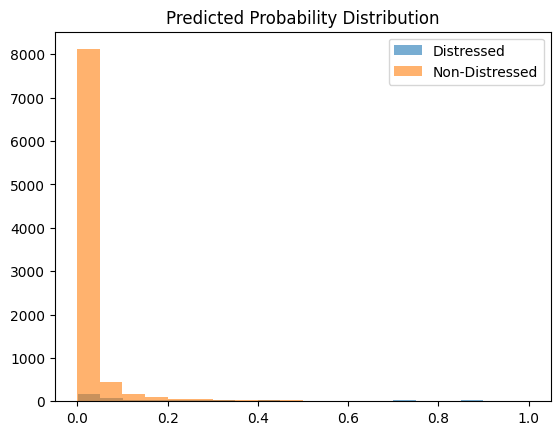

In [38]:
plt.hist(eval_df[eval_df["true_label"] == 1]["pred_proba"],bins=20,alpha=0.6,label = "Distressed")
plt.hist(eval_df[eval_df["true_label"] == 0]["pred_proba"],bins=20,alpha=0.6,label = "Non-Distressed")
plt.legend()
plt.title("Predicted Probability Distribution")
plt.show()

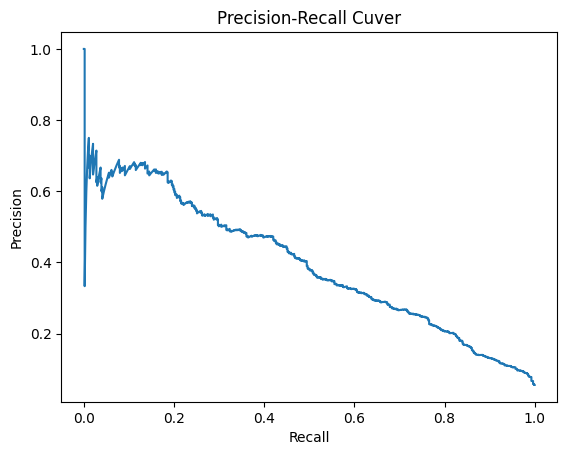

In [39]:
precision, recall, thresholds = precision_recall_curve(y_test,proba_tune)

plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Cuver")
plt.show()

# Unsupervised Learning

In [40]:
#narrow data to pre-pandemic years (2017-2019)
unsup_df = merged_df[merged_df["year"].between(2017, 2019)].copy()
unsup_df.head(5)

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,...,avg_los,occupancy_rate,payor mix,uncomp_care_ratio,resident_bed_ratio,distress_A,neg_margin,neg_margin_roll,neg_margin_yrs,distress_B
6037,669757,373026,MUSCOGEE CREEK NATION PHYSICAL REHAB,900 EAST AIRPORT ROAD,OKMULGEE,OK,74447-1118,OKMULGEE,46140.0,U,...,15.500000,0.003267,NaN,0.000000,NaN,0,0,0.0,False,0
8113,695263,450178,PECOS COUNTY MEMORIAL HOSPITAL,386 W IH-10,FORT STOCKTON,TX,79735,PECOS,99945.0,R,...,3.365385,0.035515,0.290205,0.052849,NaN,0,1,2.0,True,0
8201,688733,430096,LEWIS AND SPECIALTY HOSPITAL,2601 FOX RUN PARKWAY,YANKTON,SD,57070-,YANKTON,99943.0,R,...,2.318182,0.013973,0.049303,0.032859,NaN,0,1,2.0,True,0
8392,695139,190177,UHC(T5) LRMC(T18) TRADITIONAL(T19),92 JUDGE TANNER BLVD,COVINGTON,LA,70433,NaN,35380.0,U,...,4.559308,0.177196,0.090093,0.006966,NaN,0,1,2.0,True,0
8954,712945,340106,SANDHILLS REGIONAL MEDICAL CENTER,1000 WEST HAMLET AVE,HAMLET,NC,28345,RICHMOND,99934.0,R,...,2.198934,0.138440,0.106533,0.087694,NaN,0,1,2.0,True,0


## Version A

In [42]:
#unsupervised learning features
unsup_features = [
    "operating_margin",
    "net_margin",
    "liquidity",
    "leverage",
    "avg_los",
    "occupancy_rate"
]
# aggregate to one row per hospital averages
unsup_hosp = (
    unsup_df
    .groupby("Provider CCN", as_index=False)[unsup_features]
    .mean()
)
unsup_hosp.shape

(5028, 7)

In [43]:
#replace infinite values 
unsup_hosp[unsup_features] = unsup_hosp[unsup_features].replace([np.inf,-np.inf],np.nan)
#remove all hospitals with incomplete feature info
unsup_hosp_final = unsup_hosp.dropna(subset=unsup_features).copy()
# standardize features 
unsup_scalar = StandardScaler()
X_unsup_std = unsup_scalar.fit_transform(unsup_hosp_final[unsup_features])

Principal Component Analysis

In [44]:
#reduce dimensionality of standardized features
pca = PCA()
X_pca = pca.fit_transform(X_unsup_std)
#loadings show how strongly each feature contributes
loadings = pd.DataFrame(pca.components_.T,
                        index = unsup_features,
                        columns = [f"PC{i+1}" for i in range(len(unsup_features))])
print("PCA Loadings")
print(loadings)

print("Top Contributors PC1")
print(loadings["PC1"].sort_values(key=np.abs,ascending=False))

print("Top Contributors PC2")
print(loadings["PC2"].sort_values(key=np.abs,ascending=False))

#total variance as components is identified 
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)

PCA Loadings
                       PC1       PC2       PC3       PC4       PC5       PC6
operating_margin  0.706374  0.027025  0.022601 -0.017500 -0.014456 -0.706597
net_margin        0.706963  0.010377  0.001185 -0.002397  0.003544  0.707161
liquidity        -0.004411  0.140861  0.652329  0.744337 -0.023524  0.003890
leverage         -0.014938 -0.192333  0.748261 -0.614526  0.158312  0.013626
avg_los          -0.028542  0.674019  0.113121 -0.248633 -0.685438  0.021046
occupancy_rate   -0.013513  0.698589 -0.035559 -0.078673  0.710167 -0.000508
Top Contributors PC1
net_margin          0.706963
operating_margin    0.706374
avg_los            -0.028542
leverage           -0.014938
occupancy_rate     -0.013513
liquidity          -0.004411
Name: PC1, dtype: float64
Top Contributors PC2
occupancy_rate      0.698589
avg_los             0.674019
leverage           -0.192333
liquidity           0.140861
operating_margin    0.027025
net_margin          0.010377
Name: PC2, dtype: float64
[0.292

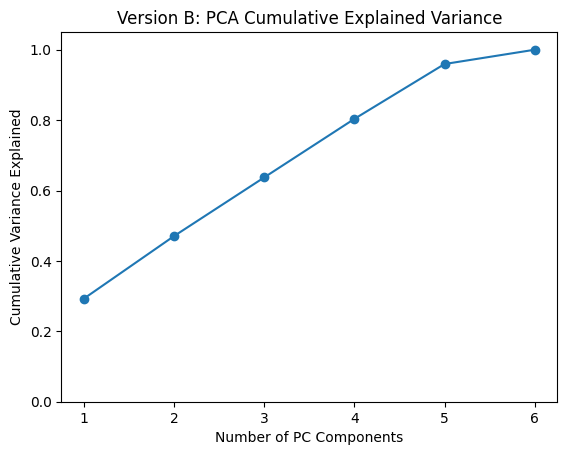

In [45]:
plt.figure()
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance, marker = "o")
plt.title("Version B: PCA Cumulative Explained Variance")
plt.xlabel("Number of PC Components")
plt.ylabel("Cumulative Variance Explained")
plt.ylim(0,1.05)
plt.show()

In [46]:
#test cluster sizes from 2-9
k_values = range(2,10)
silhouette_scores = []
#fit KMeans for each k and compute sihouette score
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X_unsup_std)
    silhouette_scores.append(silhouette_score(X_unsup_std, labels))
#store results in a dataframe for review
silhouette_df = pd.DataFrame({"k": list(k_values), "silhouette":silhouette_scores})

print("Silhouette scores by k:")
print(silhouette_df)

#select k with the highest silhouette score
silhouette_best = int(np.argmax(silhouette_scores))
k_final = list(k_values)[silhouette_best]

print("k_final")
print(k_final)

print("Max Silhouette")
print(silhouette_scores[silhouette_best])

Silhouette scores by k:
   k  silhouette
0  2    0.986883
1  3    0.977635
2  4    0.976596
3  5    0.966628
4  6    0.926169
5  7    0.508845
6  8    0.509480
7  9    0.514513
k_final
2
Max Silhouette
0.9868828322479283


The very high silhouette scores and strong dominance of a few features in the PCA loadings suggested that the clustering was being influenced by extreme finanical values. In Version B, we improved the feature set and used an improved preprocessing approach to produce clusters that better present underlying hospital characteristics rather than outlier effects. 

## Version B

In [47]:
#unsupervised numeric and categorical features
unsup_features_num = [
    "operating_margin",
    "liquidity",
    "leverage",
    "occupancy_rate",
    "CRTFD_BED_CNT",
    "payor mix",
    "uncomp_care_ratio",
    "resident_bed_ratio"
]
unsup_features_cat = [
    "CBSA_URBN_RRL_IND",
    "PRVDR_CTGRY_CD"
]
# aggregate to one row per hospital averages
fin_hosp = (
    unsup_df
    .groupby("Provider CCN", as_index=False)[unsup_features_num]
    .mean())
#categorical features per hospital
cat_hosp = (
    unsup_df
    .groupby("Provider CCN")[unsup_features_cat]
    .agg(lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else np.nan)
    .reset_index())
#merge numeric and categorical
unsup_hosp = fin_hosp.merge(cat_hosp, on="Provider CCN", how="left")
#replace infinite values 
unsup_features_B = unsup_features_num + unsup_features_cat
unsup_hosp[unsup_features_B] = unsup_hosp[unsup_features_B].replace([np.inf,-np.inf],np.nan)
#remove all hospitals with incomplete feature info
unsup_hosp_final = unsup_hosp.dropna(subset=unsup_features_B).copy()
#adjust for extreme outliers
for col in unsup_features_num:
    lo = unsup_hosp_final[col].quantile(0.01)
    hi = unsup_hosp_final[col].quantile(0.99)
    unsup_hosp_final[col] = unsup_hosp_final[col].clip(lo, hi)
#one-hot encoder categorical features
unsup_df_encoded = pd.get_dummies(unsup_hosp_final,
                                    columns = unsup_features_cat,
                                    drop_first=True)
#standardize features 
scaler = RobustScaler()
unsup_df_encoded[unsup_features_num] = scaler.fit_transform(unsup_df_encoded[unsup_features_num])
X_unsup_std= unsup_df_encoded.drop(columns=["Provider CCN"]).values

In [48]:
#reduce dimensionality of standardized features
pca = PCA()
X_pca = pca.fit_transform(X_unsup_std)
#extract feature names excluding CCN
feature_names = unsup_df_encoded.drop(columns=["Provider CCN"]).columns
#loadings show how strongly each feature contributes
loadings = pd.DataFrame(pca.components_.T,
                        index = feature_names,
                        columns = [f"PC{i+1}" for i in range(pca.n_components_)])

print("PCA Loadings")
print(loadings)

print("Top Contributors PC1")
print(loadings["PC1"].sort_values(key=np.abs,ascending=False))

print("Top Contributors PC2")
print(loadings["PC2"].sort_values(key=np.abs,ascending=False))


#total variance as components is identified 
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)

PCA Loadings
                          PC1       PC2       PC3       PC4       PC5  \
operating_margin     0.060234 -0.237074 -0.492892  0.310507  0.072208   
liquidity            0.996436  0.057780  0.042523 -0.014849 -0.030544   
leverage            -0.038614  0.958813 -0.217903  0.054782  0.103664   
occupancy_rate       0.014685 -0.034098  0.047580  0.441157  0.024574   
CRTFD_BED_CNT       -0.001611  0.006187  0.200175  0.375647  0.410482   
payor mix           -0.035011  0.112968  0.560015 -0.227061 -0.455213   
uncomp_care_ratio    0.017377 -0.034082  0.332362 -0.339680  0.776080   
resident_bed_ratio  -0.015701  0.077503  0.490437  0.627185 -0.056866   
CBSA_URBN_RRL_IND_U  0.002056  0.001957  0.028708  0.065826  0.035432   

                          PC6       PC7       PC8       PC9  
operating_margin     0.369730  0.639828 -0.222521 -0.000260  
liquidity           -0.002638 -0.028305 -0.002425 -0.001311  
leverage             0.045477  0.126000 -0.001365 -0.003389  
occupanc

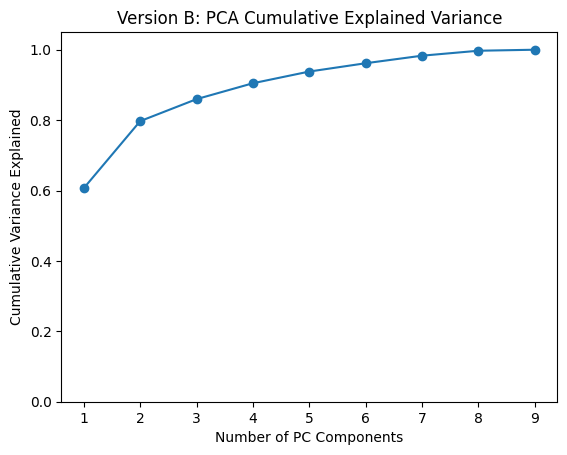

In [49]:
plt.figure()
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance, marker = "o")
plt.title("Version B: PCA Cumulative Explained Variance")
plt.xlabel("Number of PC Components")
plt.ylabel("Cumulative Variance Explained")
plt.ylim(0,1.05)
plt.show()

In [50]:
#test cluster sizes from 2-9
k_values = range(2,10)
silhouette_scores = []
#fit KMeans for each k and compute sihouette score
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X_unsup_std)
    silhouette_scores.append(silhouette_score(X_unsup_std, labels))
#store results in a dataframe for review
silhouette_df = pd.DataFrame({"k": list(k_values), "silhouette":silhouette_scores})
print("Silhouette scores by k:")
print(silhouette_df)
#select k with the highest silhouette score
silhouette_best = int(np.argmax(silhouette_scores))
k_final = list(k_values)[silhouette_best]

print("k_final")
print(k_final)

print("Max Silhouette")
print(silhouette_scores[silhouette_best])

Silhouette scores by k:
   k  silhouette
0  2    0.834330
1  3    0.574931
2  4    0.477034
3  5    0.317227
4  6    0.283532
5  7    0.177692
6  8    0.178444
7  9    0.198868
k_final
2
Max Silhouette
0.8343296177538033


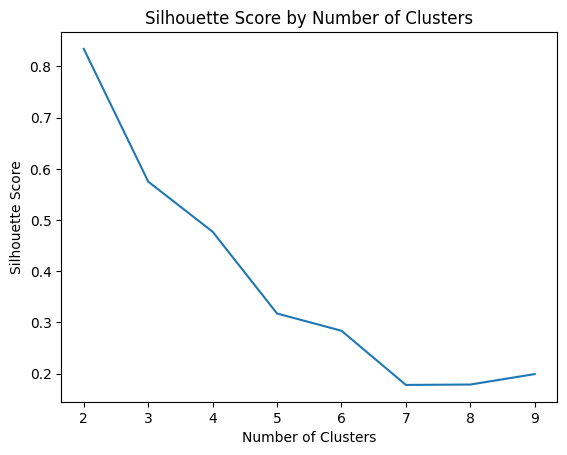

In [51]:
plt.plot(list(k_values), silhouette_scores)
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [52]:
#assign each hospital to a cluster based on feature similarity
unsup_hosp_final["cluster"] = KMeans(n_clusters=k_final, random_state=0, n_init=10).fit_predict(X_unsup_std)
#calc the average value of numeric features within each cluster
unsup_hosp_final.groupby("cluster")[unsup_features_num].mean()

,operating_margin,liquidity,leverage,occupancy_rate,CRTFD_BED_CNT,payor mix,uncomp_care_ratio,resident_bed_ratio
cluster,,,,,,,,
0,-0.040115,2.428226,0.325165,0.546727,385.843952,0.121975,0.054448,0.195054
1,0.167657,52.295510,0.059068,0.571428,330.385965,0.067861,0.089049,0.105323


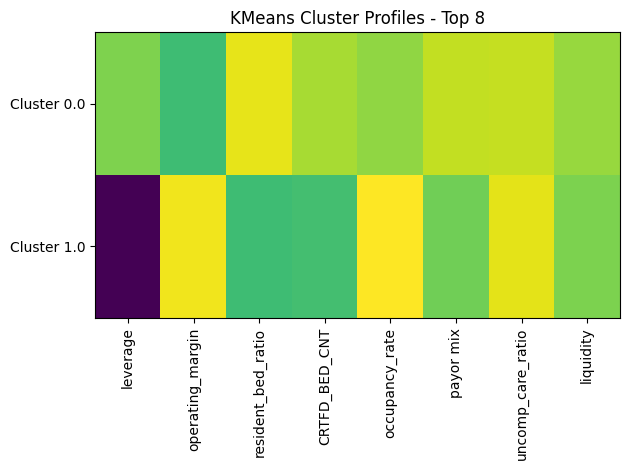

In [53]:
#convert standardized feature matrix to a dataframe
x_df = pd.DataFrame(X_unsup_std, columns=feature_names)
#calculate the average feature values within each cluster
cluster_profiles = x_df.groupby(unsup_hosp_final["cluster"]).mean()
#select 8 features with the greatest variation
top_feats = cluster_profiles.var(axis=0).sort_values(ascending=False).head(8).index
cluster_profiles_small = cluster_profiles[top_feats]
#ensure all values are numeric and clean 
cluster_profiles_small = cluster_profiles_small.apply(pd.to_numeric,errors="coerce")
cluster_profiles_small = cluster_profiles_small.replace([np.inf, -np.inf], np.nan).fillna(0.0)
#convert to array format for heatmap
heat_data = cluster_profiles_small.to_numpy(dtype=float)
#visualize cluster difference useing a heatmap
plt.imshow(heat_data, aspect="auto")
plt.yticks(range(cluster_profiles_small.shape[0]),[f"Cluster {i}" for i in cluster_profiles_small.index])
plt.xticks(range(cluster_profiles_small.shape[1]), cluster_profiles_small.columns, rotation=90)
plt.title("KMeans Cluster Profiles - Top 8")
plt.tight_layout()
plt.show()

In [54]:
#flag hospitals ever distressed
distress_hosp = (merged_df.groupby("Provider CCN", as_index=False)["distress_B"].max())
#merge distress with clusters
unsup_with_distress = unsup_hosp_final.merge(distress_hosp,on="Provider CCN",how="left")
#distress rate by cluster
unsup_with_distress.groupby("cluster")["distress_B"].mean()

cluster
0    0.113043
1    0.052632
Name: distress_B, dtype: float64

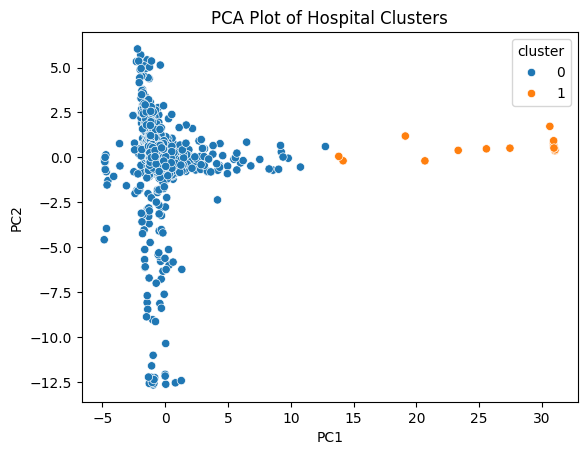

In [55]:
#build PCA dataframe with cluster labels
pca_df = unsup_hosp_final[["Provider CCN", "cluster"]].copy()
#add first two principal components
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]
#visualize clusters
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster"
)
plt.title("PCA Plot of Hospital Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [56]:
#test GMM with different numbers of components 2-9
k_values_gmm = range(2,10)
gmm_rows = []

for k in k_values_gmm:
    #fit Gaussian Mixture Model
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
    gmm.fit(X_unsup_std)
    #store model selection metrics
    gmm_rows.append({"k":k,
                        "bic": gmm.bic(X_unsup_std),
                        "aic": gmm.aic(X_unsup_std)})
#create table of results and sort by BIC
gmm_scores = pd.DataFrame(gmm_rows).sort_values("bic")
print("GMM Scores", gmm_scores)
#sort by k for plotting
gmm_sorted = gmm_scores.sort_values("k")

GMM Scores    k           bic           aic
5  7  11975.874072  10071.100544
7  9  12205.742855   9755.331077
6  8  12402.528306  10224.935653
4  6  12635.035548  11003.081145
2  4  13896.752942  12810.436789
3  5  15026.748935  13667.613657
1  3  15254.243510  14440.746483
0  2  23342.734998  22802.057096


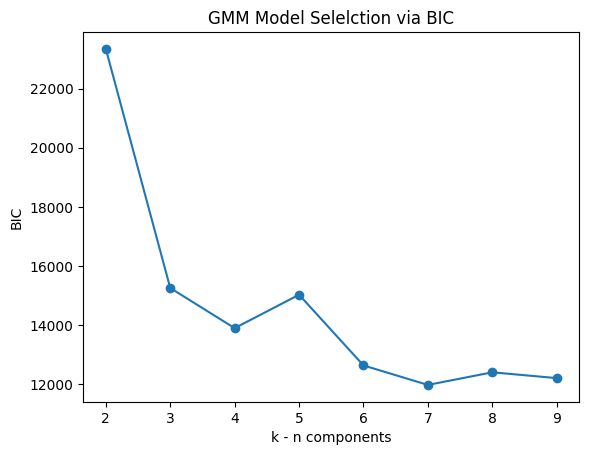

In [57]:
plt.plot(gmm_sorted["k"], gmm_sorted["bic"], marker="o")
plt.xlabel("k - n components")
plt.ylabel("BIC")
plt.title("GMM Model Selelction via BIC")
plt.show()

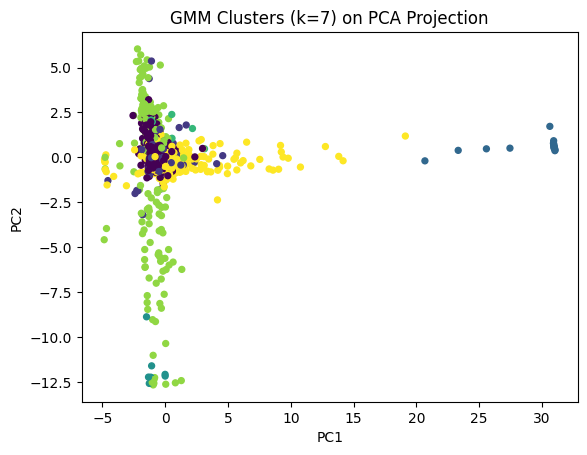

In [58]:
#select best number of components
best_gmm_k = int(gmm_scores.iloc[0]["k"])
#fit final GMM model
gmm_best = GaussianMixture(n_components=best_gmm_k, covariance_type="full", random_state=0)
#assign cluster
gmm_labels = gmm_best.fit_predict(X_unsup_std)
#reduce to 2D visualization
pca2_for_plot = PCA(n_components=2, random_state=0)
z2 = pca2_for_plot.fit_transform(X_unsup_std)

plt.scatter(z2[:,0], z2[:,1], c=gmm_labels, s=18)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"GMM Clusters (k={best_gmm_k}) on PCA Projection")
plt.show()

In [59]:
#extract best KMeans silhouette score
best_kmeans_silh = float(silhouette_df.loc[silhouette_df["k"] == k_final, "silhouette"].iloc[0])
#extract best GMM model selection metrics
best_gmm_bic = float(gmm_scores.iloc[0]["bic"])
best_gmm_aic = float(gmm_scores.iloc[0]["aic"])
#create summary table
summary_unsup = pd.DataFrame([{"family": "KMeans (centroid base)",
                                "best_hyperparams": f"k={k_final}",
                                "metric_used": "Silhouette",
                                "best_metric_value": best_kmeans_silh},
                                {"family": "GMM (probabilistic mixture)",
                                "best_hyperparams": f"k={best_gmm_k}, covariance=full",
                                "metric_used": "BIC",
                                "best_metric_value": best_gmm_bic,
                                "secondary_metric": f"AIC={best_gmm_aic:.4}"}])
summary_unsup

,family,best_hyperparams,metric_used,best_metric_value,secondary_metric
0,KMeans (centroid base),k=2,Silhouette,0.834330,NaN
1,GMM (probabilistic mixture),"k=7, covariance=full",BIC,11975.874072,AIC=1.007e+04


## Sensitivity Analysis

Sensitivity ARI: -0.02419912676735272


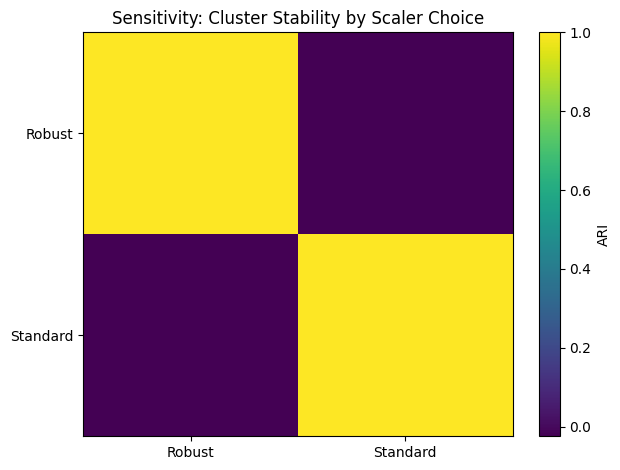

In [60]:
#save baseline cluster labels
labels_baseline = unsup_hosp_final["cluster"].values
#build alternative preprocessing using stamdardscaler
num_pipe_std = Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                                ("scale", StandardScaler())])

cat_pipe_std = Pipeline(steps=[("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown ="ignore", sparse_output = False))])
#apply standard scaling pipeline
preprocessor_std = ColumnTransformer(transformers=[
                                ("num", num_pipe_std, unsup_features_num),
                                ("cat", cat_pipe_std, unsup_features_cat)],
                                remainder = "drop",
                                verbose_feature_names_out=False)
#recalc feature matrix with StandardScaler
x_std = preprocessor_std.fit_transform(unsup_hosp_final.drop(columns=["cluster"], errors = "ignore"))
#refit Kmeans
labels_std = KMeans(n_clusters = k_final, random_state=0, n_init=10).fit_predict(x_std)
#compare cluster assingments using Adjusted Rand Index
ari_scaler= adjusted_rand_score(labels_baseline, labels_std)
print("Sensitivity ARI:", ari_scaler)

ari_mat = np.array([[1.0, ari_scaler],
                    [ari_scaler, 1.0]])
plt.imshow(ari_mat, aspect="auto")
plt.yticks([0,1], ["Robust","Standard"])
plt.xticks([0,1], ["Robust","Standard"])
plt.colorbar(label = "ARI")
plt.title("Sensitivity: Cluster Stability by Scaler Choice")
plt.tight_layout()
plt.show()